In [14]:
# 匯入套件與讀取資料
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 建立輸出資料夾，只放 CSV
output_dir = "pca_outputs"
os.makedirs(output_dir, exist_ok=True)

# 讀取資料
df = pd.read_csv("clean_dataset_final.csv")

print("資料筆數與欄位數：")
print(df.shape)

print("\n欄位名稱：")
print(df.columns.tolist())

print("\n缺失值檢查：")
print(df.isna().sum())

print("\nBody Battery 狀態分布：")
print(df["body_battery_status"].value_counts())

資料筆數與欄位數：
(801, 18)

欄位名稱：
['id', 'date', 'steps', 'active_kilocalories', 'active_time', 'resting_heart_rate', 'average_heart_rate', 'sleep_hours', 'deep_sleep_ratio', 'rem_ratio', 'awake_ratio', 'sleep_efficiency', 'sedentary_ratio', 'active_ratio', 'highly_active_ratio', 'body_battery_status', 'total_sport_hours', 'stress_hours']

缺失值檢查：
id                     0
date                   0
steps                  0
active_kilocalories    0
active_time            0
resting_heart_rate     0
average_heart_rate     0
sleep_hours            0
deep_sleep_ratio       0
rem_ratio              0
awake_ratio            0
sleep_efficiency       0
sedentary_ratio        0
active_ratio           0
highly_active_ratio    0
body_battery_status    0
total_sport_hours      0
stress_hours           0
dtype: int64

Body Battery 狀態分布：
body_battery_status
LOW         247
HIGH        240
GOOD        217
VERY_LOW     97
Name: count, dtype: int64


In [15]:
# 選擇 PCA 變數
pca_features = [
    "sleep_hours",
    "deep_sleep_ratio",
    "rem_ratio",
    "awake_ratio",
    "steps",
    "sedentary_ratio",
    "average_heart_rate",
    "stress_hours"
]

# 檢查欄位是否存在
missing_cols = [col for col in pca_features if col not in df.columns]

if len(missing_cols) > 0:
    raise ValueError(f"以下 PCA 欄位在資料中不存在：{missing_cols}")
else:
    print("PCA 使用欄位檢查通過。")

print("\n本次 PCA 使用變數：")
for col in pca_features:
    print("-", col)

# 建立 PCA 資料
X = df[pca_features].copy()
status = df["body_battery_status"].copy()

# 處理無限值
X = X.replace([np.inf, -np.inf], np.nan)

# 如果有缺失值，刪除該列
valid_index = X.dropna().index
X = X.loc[valid_index]
status = status.loc[valid_index]

print("\nPCA 實際使用資料筆數與欄位數：")
print(X.shape)

print("\nPCA 變數描述統計：")
display(X.describe())

PCA 使用欄位檢查通過。

本次 PCA 使用變數：
- sleep_hours
- deep_sleep_ratio
- rem_ratio
- awake_ratio
- steps
- sedentary_ratio
- average_heart_rate
- stress_hours

PCA 實際使用資料筆數與欄位數：
(801, 8)

PCA 變數描述統計：


,sleep_hours,deep_sleep_ratio,rem_ratio,awake_ratio,steps,sedentary_ratio,average_heart_rate,stress_hours
count,801.000000,801.000000,801.000000,801.000000,801.000000,801.000000,801.000000,801.000000
mean,6.553800,0.211478,0.171612,0.046773,3180.004934,0.752999,73.348985,1.827486
std,1.752200,0.085120,0.077267,0.064627,2370.152524,0.065258,8.458259,3.635612
min,0.016667,0.000000,0.000000,0.000000,5.333333,0.606667,52.800000,0.000000
25%,5.516667,0.153631,0.122857,0.007018,1664.666667,0.707602,67.333333,0.000000
50%,6.566667,0.200590,0.175978,0.025443,2920.833333,0.743337,72.625000,0.000000
75%,7.600000,0.258427,0.226457,0.061364,4044.833333,0.785714,77.800000,2.200000
max,12.550000,0.638298,0.384000,0.562212,19055.000000,0.989691,104.000000,34.450000


In [16]:
# 標準化 Standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=pca_features,
    index=X.index
)

print("標準化完成。")
print("標準化後資料前五筆：")
display(X_scaled_df.head())

標準化完成。
標準化後資料前五筆：


,sleep_hours,deep_sleep_ratio,rem_ratio,awake_ratio,steps,sedentary_ratio,average_heart_rate,stress_hours
0,0.159474,0.696683,-1.337972,-0.233238,0.708306,-0.684875,1.260031,-0.502977
1,-0.154455,0.771857,-0.951610,0.426518,0.109717,-0.577615,-0.698516,-0.502977
2,1.720551,-0.294670,-1.342520,0.354771,0.103220,-0.353769,0.195318,-0.502977
3,-0.149696,1.319327,-0.658561,0.366751,0.827389,-0.697914,-0.159587,0.781424
4,-0.832122,2.126974,-0.875725,-0.116609,-0.125670,0.098130,0.195318,-0.502977


In [17]:
# 完整 PCA 與 Explained Variance
pca_full = PCA()
pca_full_result = pca_full.fit_transform(X_scaled)

explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

explained_df = pd.DataFrame({
    "PC": [f"PC{i+1}" for i in range(len(explained_variance))],
    "Explained Variance Ratio": explained_variance,
    "Explained Variance Percentage": explained_variance * 100,
    "Cumulative Explained Variance": cumulative_variance,
    "Cumulative Explained Variance Percentage": cumulative_variance * 100
})

print("各主成分解釋變異量：")
display(explained_df)

# 儲存 CSV
explained_path = os.path.join(output_dir, "pca_explained_variance.csv")
explained_df.to_csv(explained_path, index=False, encoding="utf-8-sig")

print(f"已儲存：{explained_path}")

各主成分解釋變異量：


,PC,Explained Variance Ratio,Explained Variance Percentage,Cumulative Explained Variance,Cumulative Explained Variance Percentage
0,PC1,0.252436,25.243595,0.252436,25.243595
1,PC2,0.191651,19.165088,0.444087,44.408683
2,PC3,0.157838,15.783759,0.601924,60.192441
3,PC4,0.114950,11.494961,0.716874,71.687403
4,PC5,0.100065,10.006472,0.816939,81.693875
5,PC6,0.074565,7.456524,0.891504,89.150399
6,PC7,0.055091,5.509051,0.946595,94.659450
7,PC8,0.053405,5.340550,1.000000,100.000000


已儲存：pca_outputs/pca_explained_variance.csv


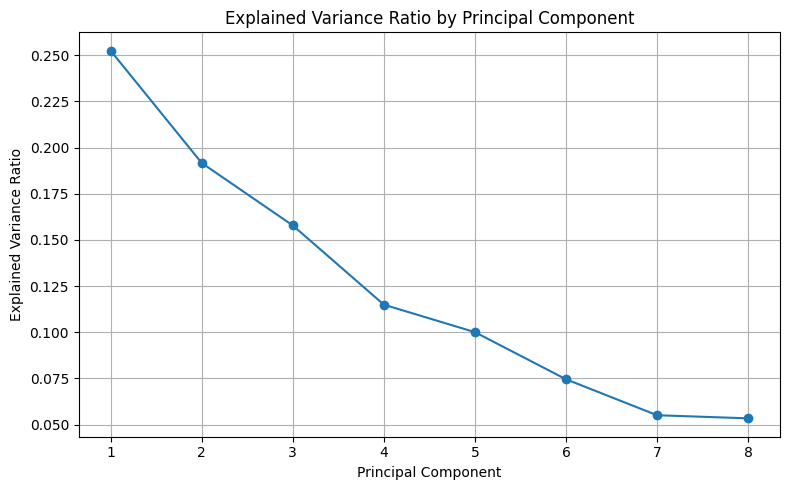

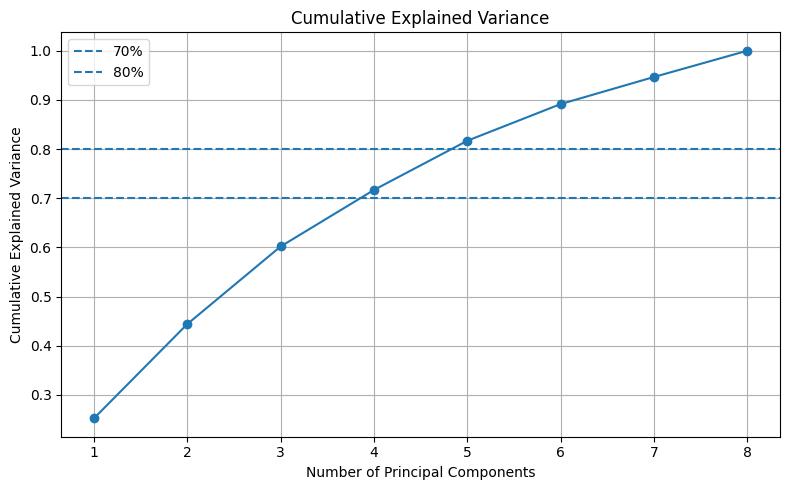

In [18]:
# Explained Variance
plt.figure(figsize=(8, 5))
plt.plot(
    range(1, len(explained_variance) + 1),
    explained_variance,
    marker="o"
)

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Explained Variance Ratio by Principal Component")
plt.grid(True)
plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 5))
plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o"
)

plt.axhline(y=0.70, linestyle="--", label="70%")
plt.axhline(y=0.80, linestyle="--", label="80%")

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [19]:
# PC1-PC4 PCA

pca_4 = PCA(n_components=4)
pca_4_result = pca_4.fit_transform(X_scaled)

pca_scores_df = pd.DataFrame(
    pca_4_result,
    columns=["PC1", "PC2", "PC3", "PC4"],
    index=X.index
)

pca_scores_df["body_battery_status"] = status.values

print("PC1-PC4 分數資料前五筆：")
display(pca_scores_df.head())

print("\nPC1-PC4 解釋變異量：")
for i, ratio in enumerate(pca_4.explained_variance_ratio_):
    print(f"PC{i+1}: {ratio:.4f} ({ratio*100:.2f}%)")

print("\nPC1-PC4 累積解釋變異量：")
print(f"{pca_4.explained_variance_ratio_.sum():.4f} ({pca_4.explained_variance_ratio_.sum()*100:.2f}%)")

# 儲存 CSV
scores_path = os.path.join(output_dir, "pca_scores_pc1_pc4.csv")
pca_scores_df.to_csv(scores_path, index=False, encoding="utf-8-sig")

print(f"已儲存：{scores_path}")

PC1-PC4 分數資料前五筆：


,PC1,PC2,PC3,PC4,body_battery_status
0,-1.451943,-0.123937,0.616279,-0.066796,GOOD
1,-1.056967,-0.016548,-0.899527,0.338497,GOOD
2,0.243990,-0.408414,0.314559,0.991576,LOW
3,-1.536584,0.316404,0.272301,-0.062744,LOW
4,-1.712784,-0.512064,-0.997069,-1.187648,LOW



PC1-PC4 解釋變異量：
PC1: 0.2524 (25.24%)
PC2: 0.1917 (19.17%)
PC3: 0.1578 (15.78%)
PC4: 0.1149 (11.49%)

PC1-PC4 累積解釋變異量：
0.7169 (71.69%)
已儲存：pca_outputs/pca_scores_pc1_pc4.csv


In [20]:
# PC1-PC4 Loading Table
loadings_4 = pd.DataFrame(
    pca_4.components_.T,
    columns=["PC1_loading", "PC2_loading", "PC3_loading", "PC4_loading"],
    index=pca_features
)

print("PC1-PC4 Loading Table：")
display(loadings_4)

# 儲存 CSV
loadings_path = os.path.join(output_dir, "pca_loadings_pc1_pc4.csv")
loadings_4.to_csv(loadings_path, encoding="utf-8-sig")

print(f"已儲存：{loadings_path}")

# 額外在畫面上顯示每個 PC 影響最大的變數，但不另外存 CSV
for pc in ["PC1", "PC2", "PC3", "PC4"]:
    loading_col = f"{pc}_loading"

    temp = loadings_4[[loading_col]].copy()
    temp["abs_loading"] = temp[loading_col].abs()
    temp = temp.sort_values("abs_loading", ascending=False)

    print(f"\n{pc} 主要影響變數：")
    display(temp)

PC1-PC4 Loading Table：


,PC1_loading,PC2_loading,PC3_loading,PC4_loading
sleep_hours,0.555046,0.085389,0.185454,0.188113
deep_sleep_ratio,-0.441665,0.017259,-0.311281,-0.472745
rem_ratio,0.440201,0.446960,-0.068132,-0.051546
awake_ratio,-0.160130,-0.434286,-0.126104,0.727328
steps,-0.319426,0.506356,0.270061,0.286199
sedentary_ratio,0.388476,-0.497739,-0.111171,-0.269518
average_heart_rate,-0.155788,-0.307993,0.587724,-0.122625
stress_hours,-0.014868,-0.070951,0.646108,-0.199689


已儲存：pca_outputs/pca_loadings_pc1_pc4.csv

PC1 主要影響變數：


,PC1_loading,abs_loading
sleep_hours,0.555046,0.555046
deep_sleep_ratio,-0.441665,0.441665
rem_ratio,0.440201,0.440201
sedentary_ratio,0.388476,0.388476
steps,-0.319426,0.319426
awake_ratio,-0.160130,0.160130
average_heart_rate,-0.155788,0.155788
stress_hours,-0.014868,0.014868



PC2 主要影響變數：


,PC2_loading,abs_loading
steps,0.506356,0.506356
sedentary_ratio,-0.497739,0.497739
rem_ratio,0.446960,0.446960
awake_ratio,-0.434286,0.434286
average_heart_rate,-0.307993,0.307993
sleep_hours,0.085389,0.085389
stress_hours,-0.070951,0.070951
deep_sleep_ratio,0.017259,0.017259



PC3 主要影響變數：


,PC3_loading,abs_loading
stress_hours,0.646108,0.646108
average_heart_rate,0.587724,0.587724
deep_sleep_ratio,-0.311281,0.311281
steps,0.270061,0.270061
sleep_hours,0.185454,0.185454
awake_ratio,-0.126104,0.126104
sedentary_ratio,-0.111171,0.111171
rem_ratio,-0.068132,0.068132



PC4 主要影響變數：


,PC4_loading,abs_loading
awake_ratio,0.727328,0.727328
deep_sleep_ratio,-0.472745,0.472745
steps,0.286199,0.286199
sedentary_ratio,-0.269518,0.269518
stress_hours,-0.199689,0.199689
sleep_hours,0.188113,0.188113
average_heart_rate,-0.122625,0.122625
rem_ratio,-0.051546,0.051546


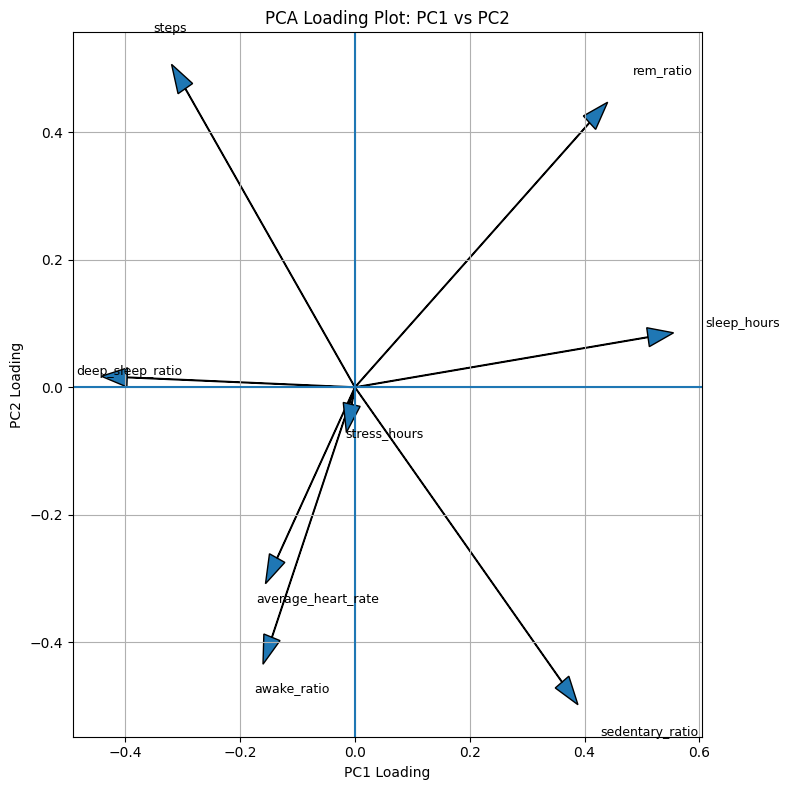

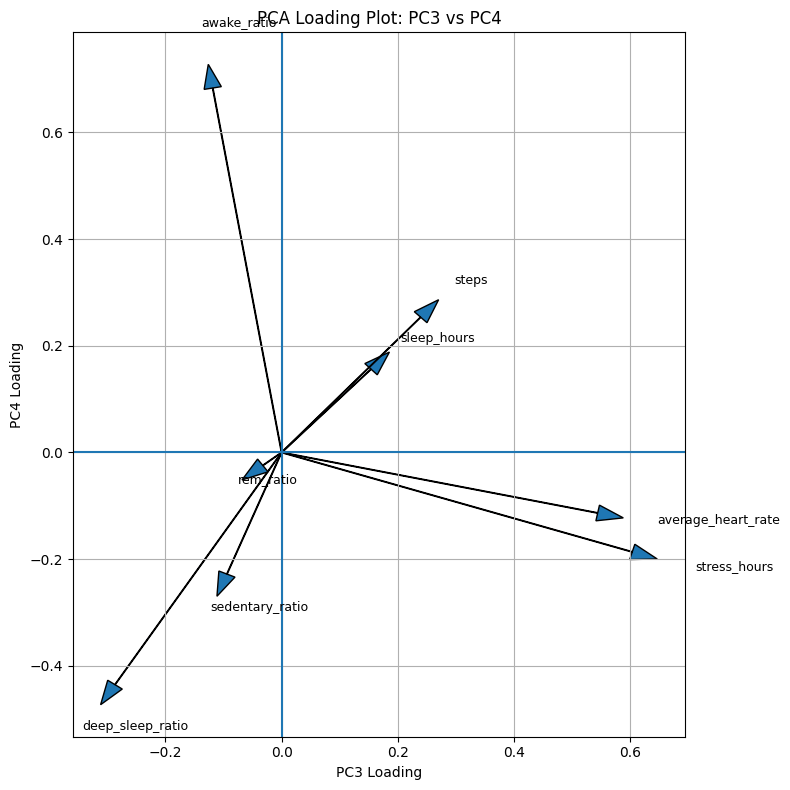

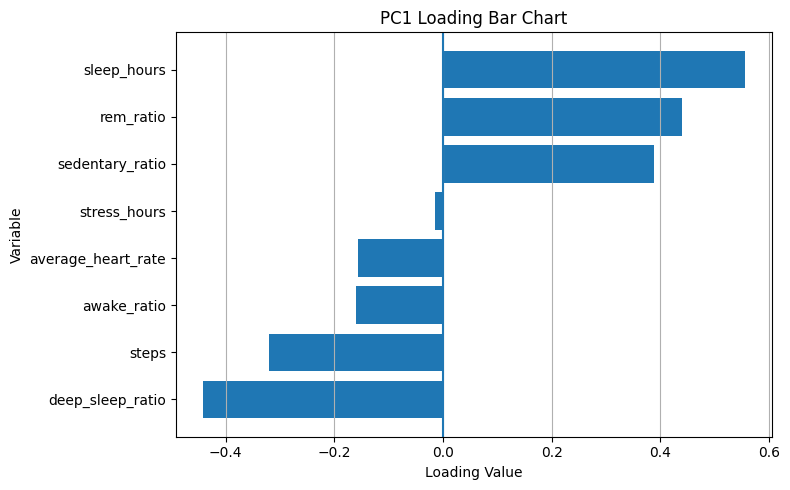

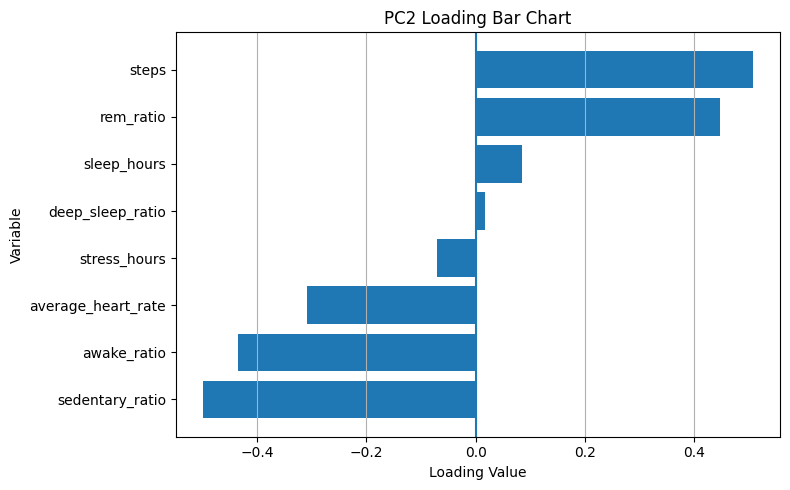

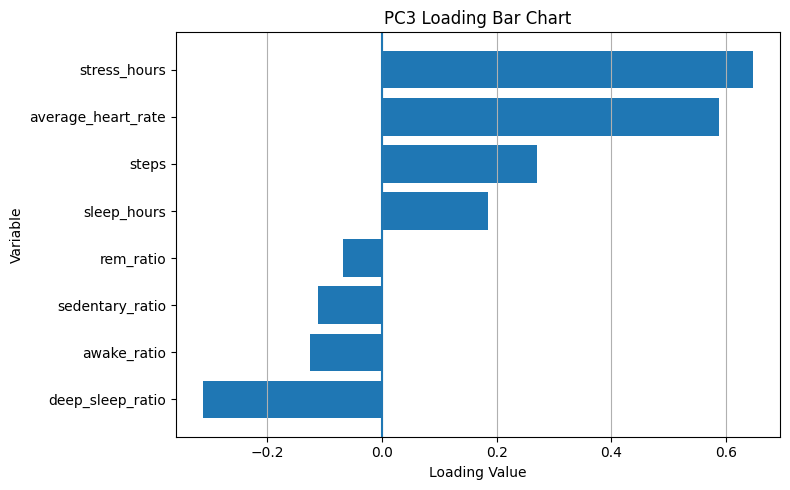

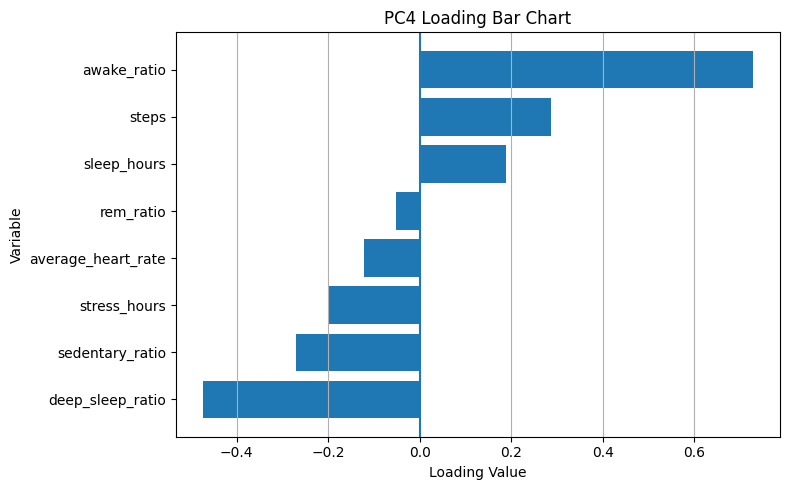

In [21]:
# PC1-PC2 Loading Plot
plt.figure(figsize=(8, 8))

for feature in pca_features:
    plt.arrow(
        0,
        0,
        loadings_4.loc[feature, "PC1_loading"],
        loadings_4.loc[feature, "PC2_loading"],
        head_width=0.03,
        length_includes_head=True
    )
    plt.text(
        loadings_4.loc[feature, "PC1_loading"] * 1.1,
        loadings_4.loc[feature, "PC2_loading"] * 1.1,
        feature,
        fontsize=9
    )

plt.axhline(0)
plt.axvline(0)
plt.xlabel("PC1 Loading")
plt.ylabel("PC2 Loading")
plt.title("PCA Loading Plot: PC1 vs PC2")
plt.grid(True)
plt.tight_layout()
plt.show()


# PC3-PC4 Loading Plot
plt.figure(figsize=(8, 8))

for feature in pca_features:
    plt.arrow(
        0,
        0,
        loadings_4.loc[feature, "PC3_loading"],
        loadings_4.loc[feature, "PC4_loading"],
        head_width=0.03,
        length_includes_head=True
    )
    plt.text(
        loadings_4.loc[feature, "PC3_loading"] * 1.1,
        loadings_4.loc[feature, "PC4_loading"] * 1.1,
        feature,
        fontsize=9
    )

plt.axhline(0)
plt.axvline(0)
plt.xlabel("PC3 Loading")
plt.ylabel("PC4 Loading")
plt.title("PCA Loading Plot: PC3 vs PC4")
plt.grid(True)
plt.tight_layout()
plt.show()


# PC1-PC4 Loading Bar Charts
for pc in ["PC1", "PC2", "PC3", "PC4"]:
    loading_col = f"{pc}_loading"
    sorted_loadings = loadings_4[loading_col].sort_values()

    plt.figure(figsize=(8, 5))
    plt.barh(sorted_loadings.index, sorted_loadings.values)

    plt.axvline(0)
    plt.xlabel("Loading Value")
    plt.ylabel("Variable")
    plt.title(f"{pc} Loading Bar Chart")
    plt.grid(axis="x")
    plt.tight_layout()
    plt.show()

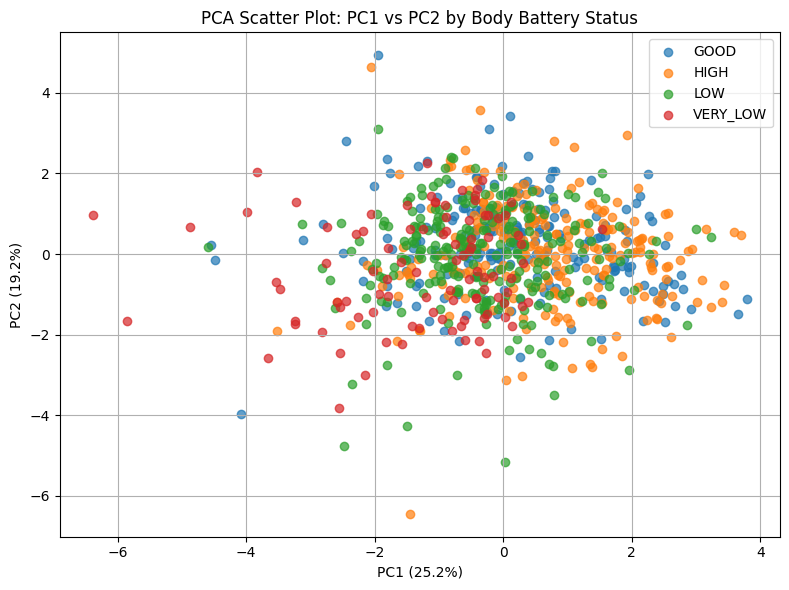

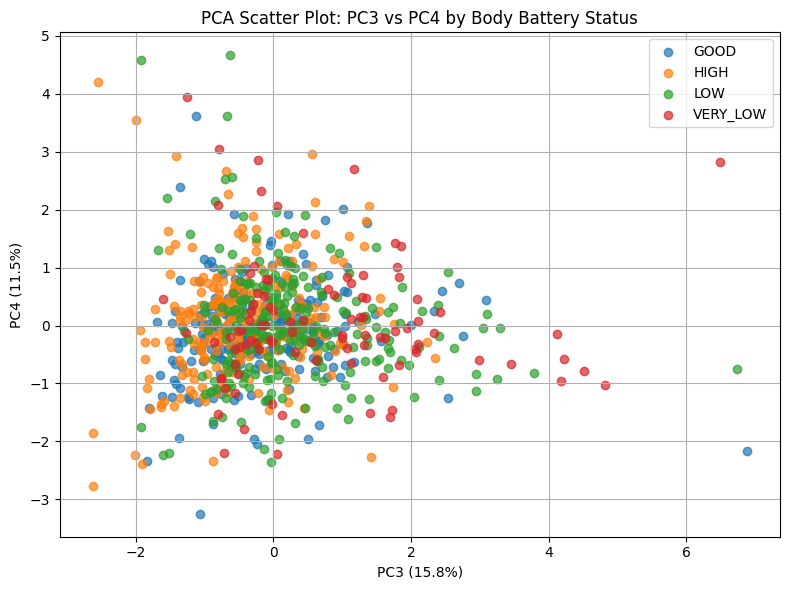

In [22]:
# PCA Scatter Plot by Body Battery Status
# PC1-PC2 Scatter Plot
plt.figure(figsize=(8, 6))

for group in sorted(pca_scores_df["body_battery_status"].unique()):
    subset = pca_scores_df[pca_scores_df["body_battery_status"] == group]
    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        label=group,
        alpha=0.7
    )

plt.xlabel(f"PC1 ({pca_4.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca_4.explained_variance_ratio_[1]*100:.1f}%)")
plt.title("PCA Scatter Plot: PC1 vs PC2 by Body Battery Status")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# PC3-PC4 Scatter Plot
plt.figure(figsize=(8, 6))

for group in sorted(pca_scores_df["body_battery_status"].unique()):
    subset = pca_scores_df[pca_scores_df["body_battery_status"] == group]
    plt.scatter(
        subset["PC3"],
        subset["PC4"],
        label=group,
        alpha=0.7
    )

plt.xlabel(f"PC3 ({pca_4.explained_variance_ratio_[2]*100:.1f}%)")
plt.ylabel(f"PC4 ({pca_4.explained_variance_ratio_[3]*100:.1f}%)")
plt.title("PCA Scatter Plot: PC3 vs PC4 by Body Battery Status")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()